# Genres describe the movie, not the person

Each movie carries 19 flags. Across 1682 movies the flags sum to 2893, so the average movie carries more than one genre. 849 movies carry two or more. None carry zero. The fullest genres are Drama, 725 movies, and Comedy, 505. The rarest named genres are Fantasy, 22, and Film-Noir, 24. The flag called unknown is on for 2 movies.

*Toy Story* is Animation, Children's, and Comedy. That sentence is true whether or not user 1 liked it. A content model can say "this person likes animation" only after it looks at ratings. The flags by themselves do not rank two animated movies for one person.

This is the cut between the two families of recommender. Collaborative filtering, which is what the bias formula and the neighbor formula do, uses the rating matrix. A content model uses the genre flags, the year, or the cast. MovieLens supports both readings. The score in the holdout lesson used only the ratings.


In [2]:
# Locate the MovieLens tables beside this notebook, or under the course root.
from pathlib import Path

def data_path(name):
    here = Path.cwd()
    for folder in [here, *here.parents]:
        nested = folder / "15-Movie Recommendation" / "data" / name
        direct = folder / "data" / name
        if nested.exists():
            return nested
        if direct.exists() and (folder / "data" / "u.info").exists():
            return direct
    raise FileNotFoundError(name)

def read_lines(name):
    return data_path(name).read_text(encoding="latin-1").splitlines()

def read_ratings(name):
    rows = []
    for line in read_lines(name):
        if not line.strip():
            continue
        user, item, rating, stamp = line.split("\t")
        rows.append((int(user), int(item), int(rating), int(stamp)))
    return rows

ratings = read_ratings("u.data")
print(len(ratings), ratings[0])


100000 (196, 242, 3, 881250949)


In [3]:
# Count genre flags. A movie may add one to several counters.
genres = [line.split("|")[0] for line in read_lines("u.genre") if line.strip()]
movies = [line.split("|") for line in read_lines("u.item")]
counts = [0] * 19
multi = 0
for movie in movies:
    flags = [int(flag) for flag in movie[5:]]
    for index, flag in enumerate(flags):
        counts[index] += flag
    multi += sum(flags) > 1
print(list(zip(genres, counts)), sum(counts), multi)
assert genres[8] == "Drama" and counts[8] == 725
assert genres[5] == "Comedy" and counts[5] == 505
assert counts[9] == 22 and counts[10] == 24 and counts[0] == 2
assert sum(counts) == 2893
assert multi == 849
assert all(sum(int(flag) for flag in movie[5:]) > 0 for movie in movies)


[('unknown', 2), ('Action', 251), ('Adventure', 135), ('Animation', 42), ("Children's", 122), ('Comedy', 505), ('Crime', 109), ('Documentary', 50), ('Drama', 725), ('Fantasy', 22), ('Film-Noir', 24), ('Horror', 92), ('Musical', 56), ('Mystery', 61), ('Romance', 247), ('Sci-Fi', 101), ('Thriller', 251), ('War', 71), ('Western', 27)] 2893 849


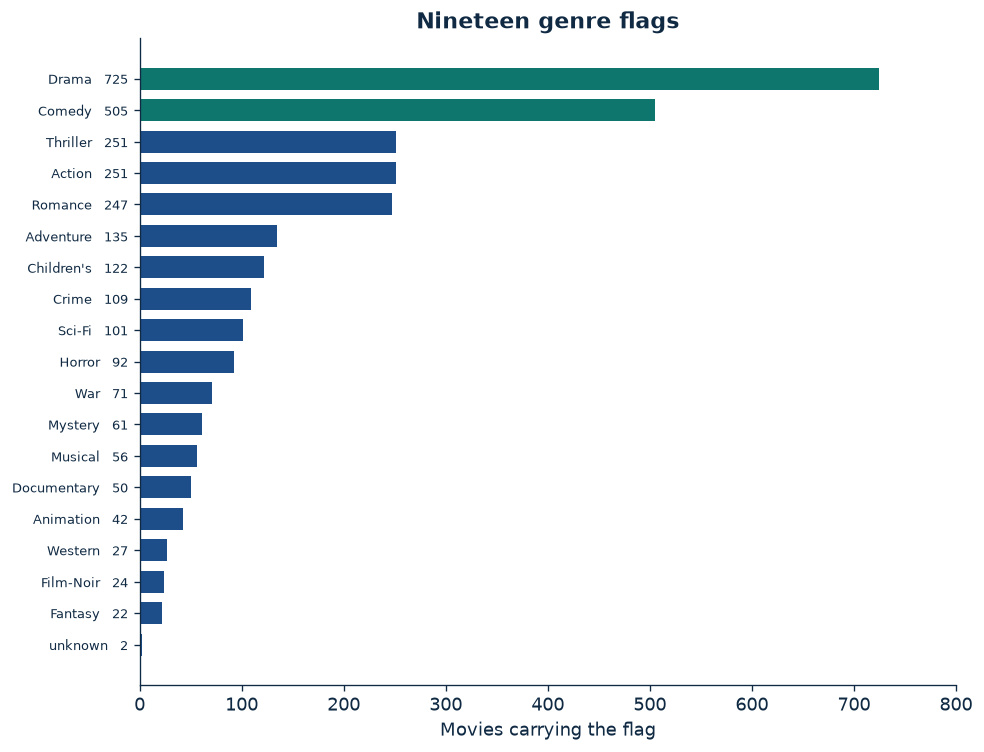

In [4]:
import matplotlib.pyplot as plt
plt.rcParams.update({
    "axes.titleweight": "bold",
    "axes.spines.top": False,
    "axes.spines.right": False,
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "axes.edgecolor": "#102a43",
    "axes.labelcolor": "#102a43",
    "xtick.color": "#102a43",
    "ytick.color": "#102a43",
    "text.color": "#102a43",
})
# Genre flags, smallest at the bottom, axis starting at zero.
genres = [line.split("|")[0] for line in read_lines("u.genre") if line.strip()]
movies = [line.split("|") for line in read_lines("u.item")]
counts = [0] * 19
for movie in movies:
    for index, flag in enumerate(movie[5:]):
        counts[index] += int(flag)
ranked = sorted(zip(counts, genres))
figure, axis = plt.subplots(figsize=(8.4, 6.4))
positions = list(range(len(ranked)))
colors = ["#0f766e" if name in ("Drama", "Comedy") else "#1d4e89" for _, name in ranked]
axis.barh(positions, [count for count, _ in ranked], color=colors, height=0.7)
axis.set_yticks(positions, [f"{name}   {count}" for count, name in ranked], fontsize=8)
axis.set_xlim(0, 800)
axis.set_xlabel("Movies carrying the flag")
axis.set_title("Nineteen genre flags")
figure.tight_layout()


## Pitfall

Drama's 725 and Comedy's 505 count movies, and a movie in both is in both bars. Adding the nineteen counts gives 2893 flags, not 1682 movies.

## Summary

Genres are flags on the movie. 849 movies have more than one. The rating model in the holdout lesson never reads these flags.
